In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Load your clean master dataframe
master = pd.read_csv("data/processed/master.csv")

# Set a clean visual style for all charts
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 120

print(f"Loaded {len(master):,} counties")
print(master.head(3))

Loaded 2,947 counties
      county           state   fips  population  depression_rate  \
0  Abbeville  South Carolina  45001       24434            24.00   
1     Acadia       Louisiana  22001       56489            31.00   
2   Accomack        Virginia  51001       33239            22.55   

   mental_distress_rate  income   age  poverty  broadband  state_code  \
0                 18.55   45710  44.3     4072       6867          45   
1                 22.20   42368  36.8    13209      16787          22   
2                 18.15   50601  47.1     5593      10899          51   

   county_code       sci  poverty_rate  broadband_rate income_quartile  
0            1  0.364204     16.665302       28.104281          Q1 Low  
1            1  0.435191     23.383314       29.717290          Q1 Low  
2            1  0.410062     16.826619       32.789795      Q2 Mid-Low  


In [2]:
master.head(10)

,county,state,fips,population,depression_rate,mental_distress_rate,income,age,poverty,broadband,state_code,county_code,sci,poverty_rate,broadband_rate,income_quartile
0,Abbeville,South Carolina,45001,24434,24.00,18.55,45710,44.3,4072,6867,45,1,0.364204,16.665302,28.104281,Q1 Low
1,Acadia,Louisiana,22001,56489,31.00,22.20,42368,36.8,13209,16787,22,1,0.435191,23.383314,29.717290,Q1 Low
2,Accomack,Virginia,51001,33239,22.55,18.15,50601,47.1,5593,10899,51,1,0.410062,16.826619,32.789795,Q2 Mid-Low
3,Ada,Idaho,16001,524673,25.25,15.50,75115,37.7,43553,168392,16,1,0.510118,8.300980,32.094657,Q4 High
4,Adair,Iowa,19001,7389,21.05,17.25,57944,43.4,837,2424,19,1,0.433395,11.327649,32.805522,Q3 Mid-High
5,Adair,Missouri,29001,25122,27.40,19.35,46639,28.1,5258,6971,29,1,0.528510,20.929862,27.748587,Q1 Low
6,Adair,Oklahoma,40001,19627,26.65,21.75,37940,37.8,4814,3563,40,1,0.270307,24.527437,18.153564,Q1 Low
7,Adams,Idaho,16003,4903,22.75,16.35,52746,54.7,688,1184,16,3,0.295881,14.032225,24.148481,Q2 Mid-Low
8,Adams,Iowa,19003,3544,21.15,16.65,57981,46.7,424,1267,19,3,0.435711,11.963883,35.750564,Q3 Mid-High
9,Adams,Colorado,8001,533365,20.50,17.00,78304,34.2,48959,159432,8,1,0.492962,9.179267,29.891725,Q4 High


In [ ]:
## 2 digits (50 states)
## 3 digits (up to 999 counties)


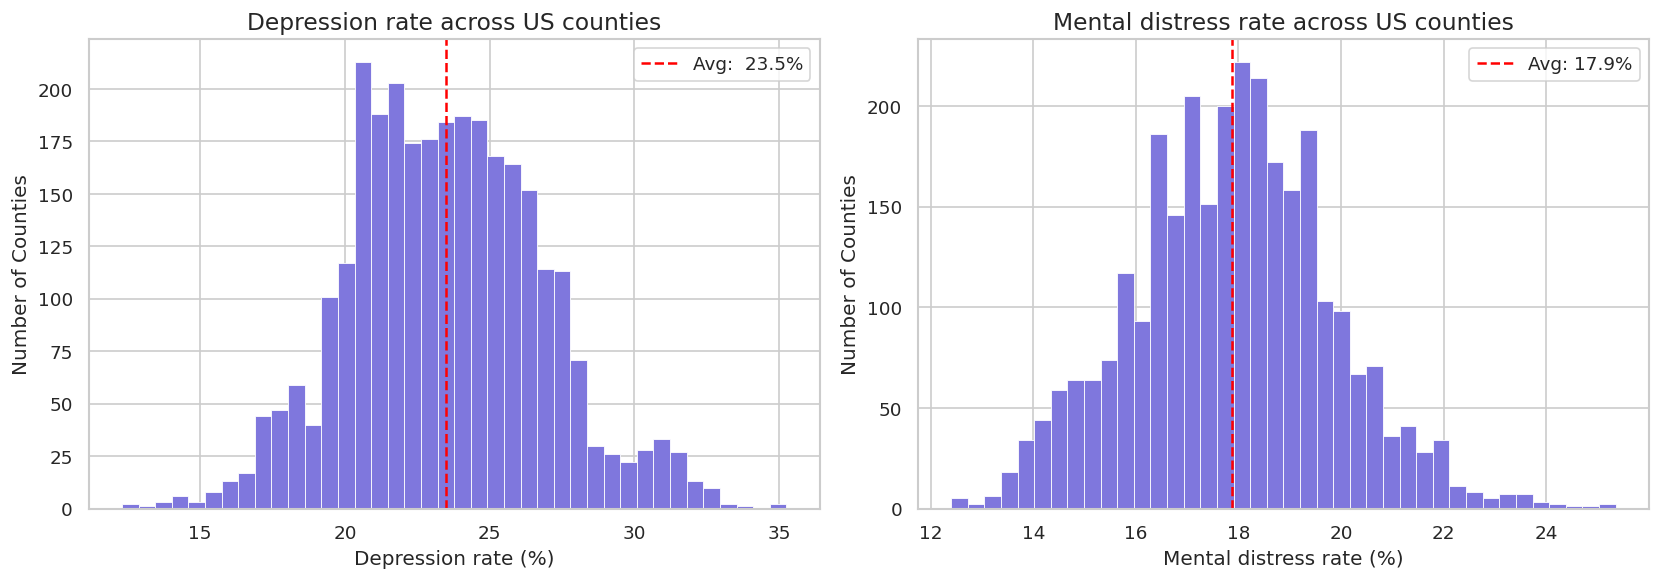

Chart 1 saved!!


In [3]:
fig, axes = plt.subplots(1, 2, figsize = (14, 5))

# dipression rate distribution
axes[0].hist(master['depression_rate'], bins=40, 
             color='#7F77DD', edgecolor='white', linewidth=0.5)
axes[0].set_title('Depression rate across US counties', fontsize=14)
axes[0].set_xlabel('Depression rate (%)')
axes[0].set_ylabel('Number of Counties')
axes[0].axvline(master['depression_rate'].mean(), color = 'red', linestyle ='--', linewidth = 1.5, label = f"Avg: {master['depression_rate'].mean(): .1f}%")
axes[0].legend()

# Mnental health provider rate distribution
axes[1].hist(master['mental_distress_rate'], bins=40, 
             color='#7F77DD', edgecolor='white', linewidth=0.5)
axes[1].set_title('Mental distress rate across US counties', fontsize=14)
axes[1].set_xlabel('Mental distress rate (%)')
axes[1].set_ylabel('Number of Counties')
axes[1].axvline(master['mental_distress_rate'].mean(), color = 'red', linestyle = '--', linewidth = 1.5, label = f"Avg: {master['mental_distress_rate'].mean():.1f}%")
axes[1].legend()

plt.tight_layout()
plt.savefig("data/processed/chart1_distributions.png" ,dpi = 120)
plt.show()
print("Chart 1 saved!!")
      


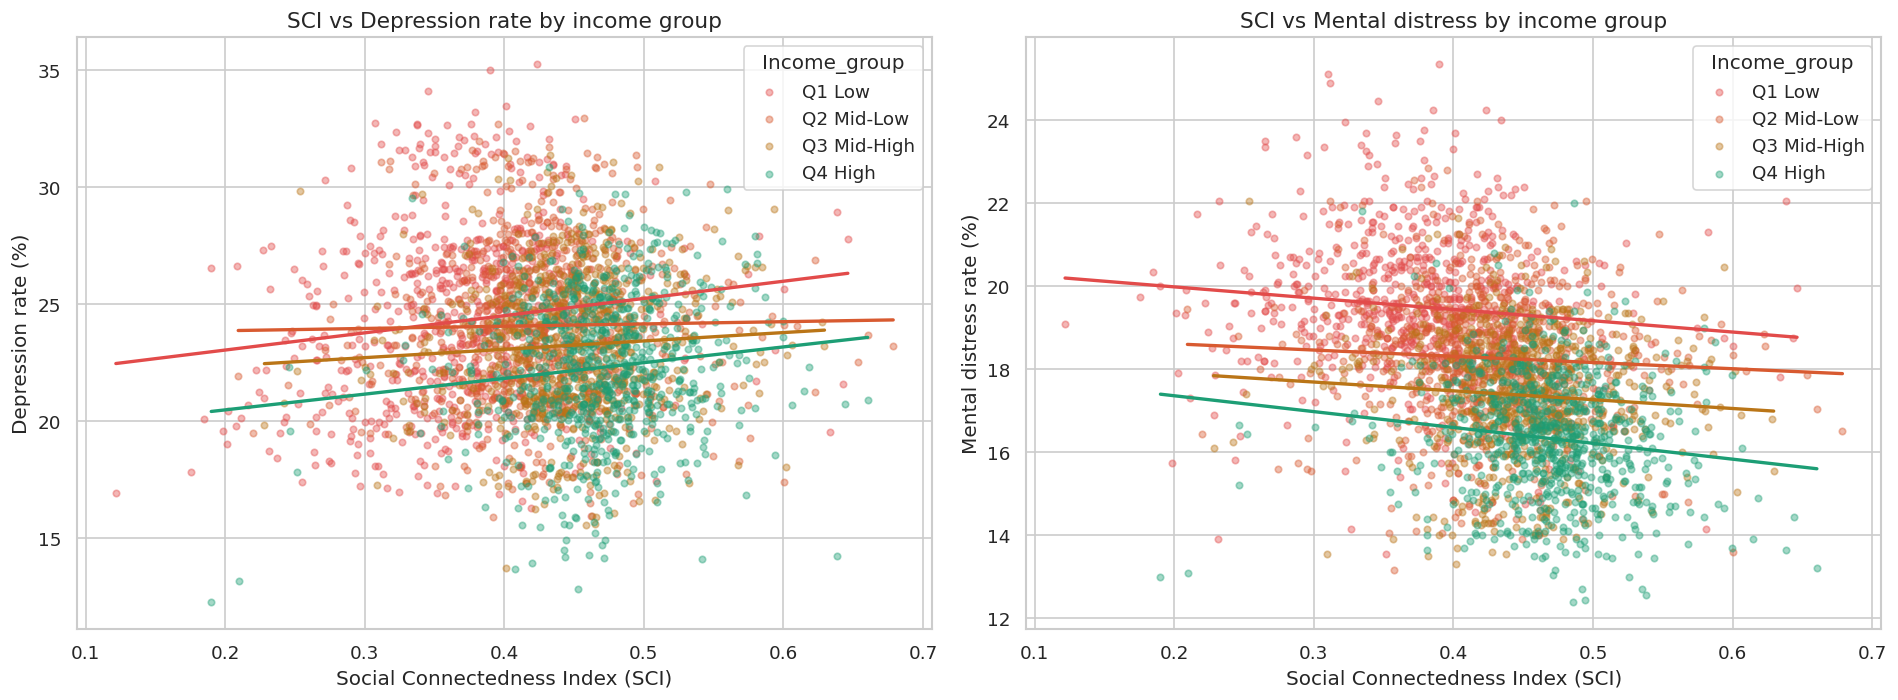

Chart 2 saved!


In [19]:
fig, axes = plt.subplots(1, 2, figsize = (16, 6))

colors = {
    'Q1 Low':      '#E24B4A',
    'Q2 Mid-Low':  '#D85A30', 
    'Q3 Mid-High': '#BA7517',
    'Q4 High':     '#1D9E75'
}

for quartile, color in colors.items():
    subset = master[master['income_quartile'] == quartile]

    #Left chart: SCI vs Dipression

    axes[0].scatter(subset['sci'], subset['depression_rate'], alpha = 0.4, s=15,  color=color, label = quartile)

    #Add trend line per quartile

    z = np.polyfit(subset['sci'], subset['depression_rate'], 1)
    p = np.poly1d(z)
    x_line = np.linspace(subset['sci'].min(), subset['sci'].max(), 100)
    axes[0].plot(x_line, p(x_line), color = color, linewidth = 2)

    #right chart: SCI vs Mental distress

    axes[1].scatter(subset['sci'], subset['mental_distress_rate'], alpha = 0.4, s = 15, color=color, label = quartile)
    z2 = np.polyfit(subset['sci'], subset['mental_distress_rate'], 1)
    p2 = np.poly1d(z2)
    axes[1].plot(x_line, p2(x_line), color = color, linewidth = 2)
    
axes[0].set_title('SCI vs Depression rate by income group', fontsize= 13)
axes[0].set_xlabel('Social Connectedness Index (SCI)')
axes[0].set_ylabel('Depression rate (%)')
axes[0].legend(title = 'Income_group')

axes[1].set_title('SCI vs Mental distress by income group', fontsize= 13)
axes[1].set_xlabel('Social Connectedness Index (SCI)')
axes[1].set_ylabel('Mental distress rate (%)')
axes[1].legend(title = 'Income_group')

plt.tight_layout()
plt.savefig('data/processed/chart2_paradox.png', dpi = 120)
plt.show()
print('Chart 2 saved!')


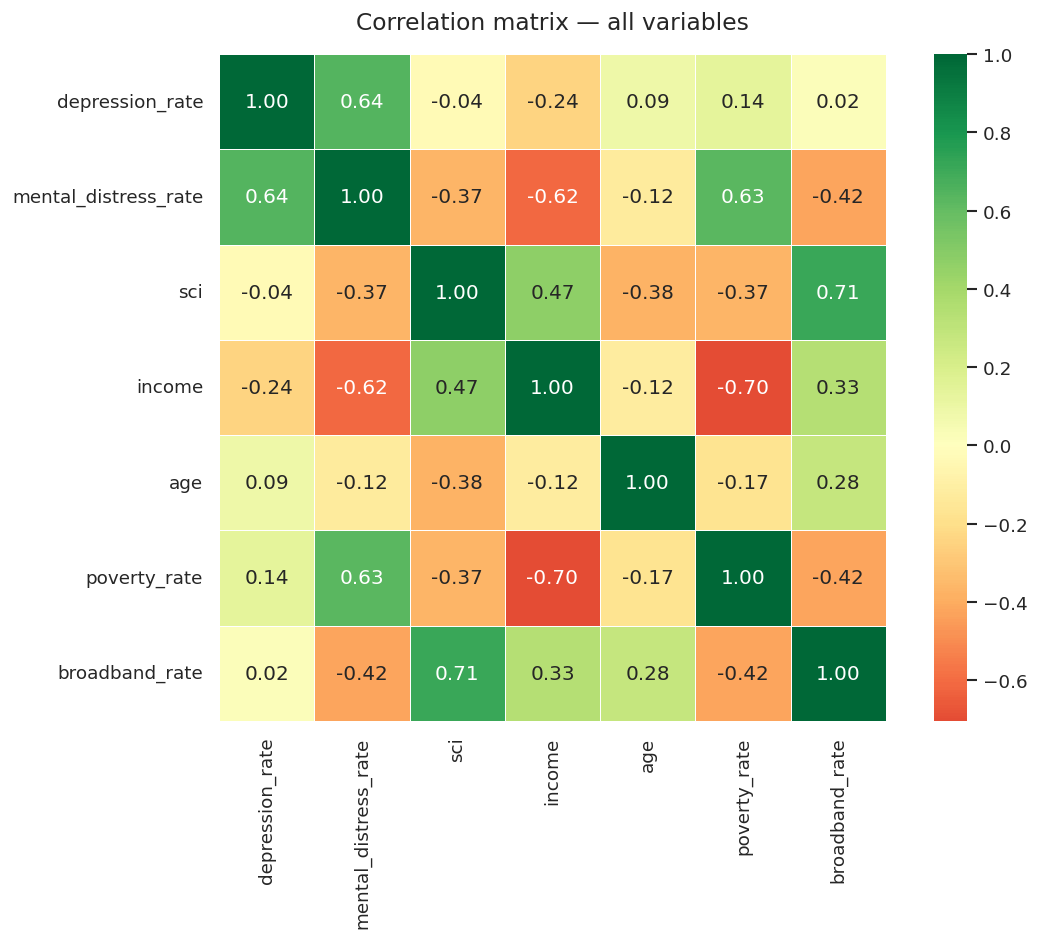

Chart 3 saved!


In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select only numeric columns for correlation
numeric_cols = [
    'depression_rate', 'mental_distress_rate',
    'sci', 'income', 'age', 
    'poverty_rate', 'broadband_rate'
]

corr_matrix = master[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))

sns.heatmap(
    corr_matrix,
    annot=True,           # show numbers inside boxes
    fmt='.2f',            # round to 2 decimal places
    cmap='RdYlGn',        # red = negative, green = positive
    center=0,             # white = no correlation
    square=True,          # equal sized boxes
    linewidths=0.5,
    ax=ax
)

ax.set_title('Correlation matrix — all variables', fontsize=14, pad=15)
plt.tight_layout()
plt.savefig('data/processed/chart3_correlation.png', dpi=120)
plt.show()
print('Chart 3 saved!')

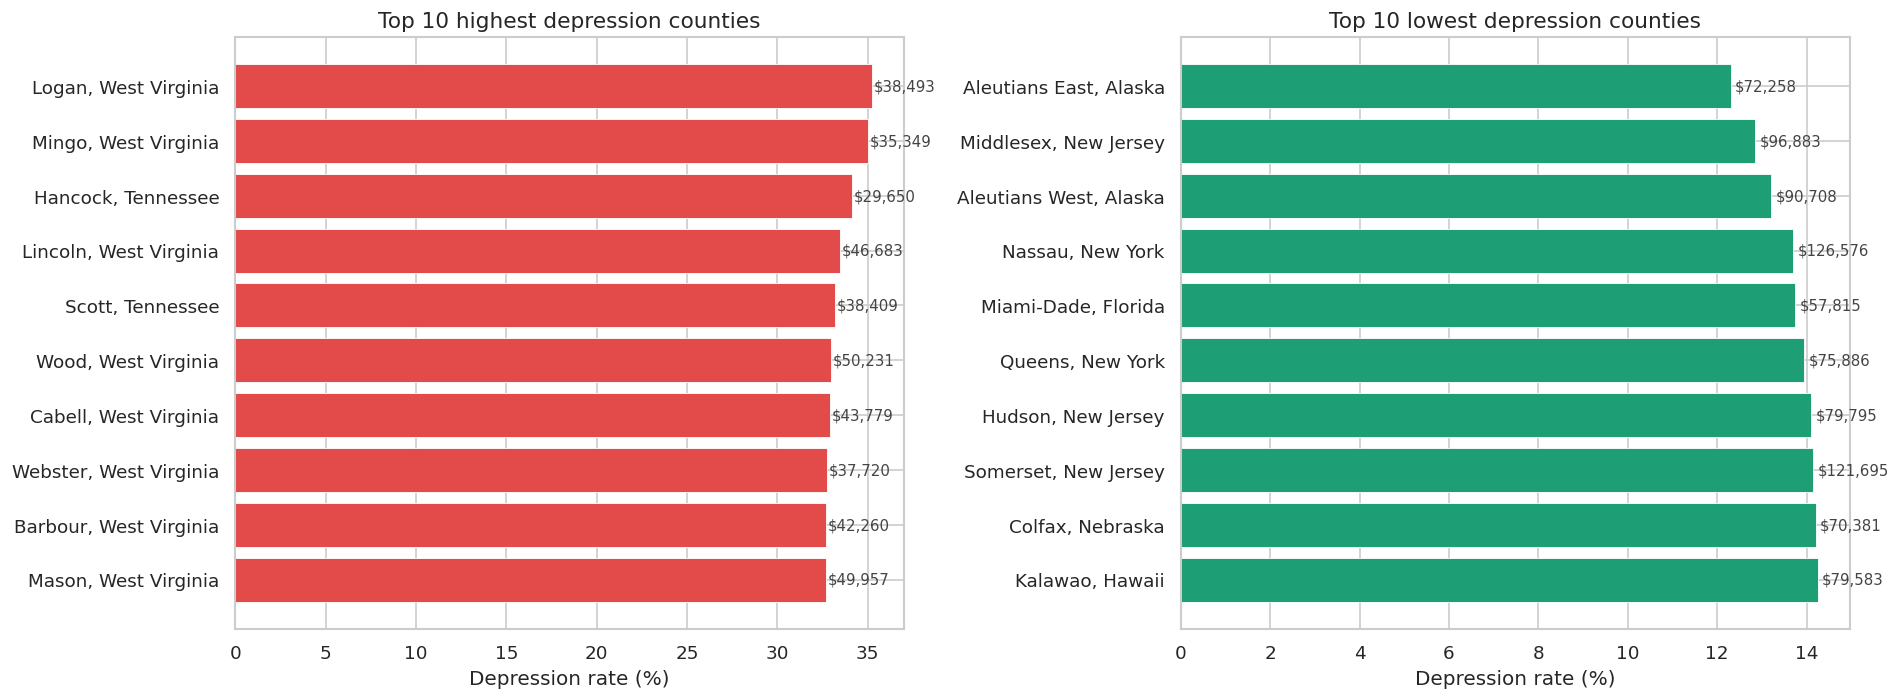

Chart 4 saved!


In [26]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Top 10 highest depression counties
top10 = master.nlargest(10, 'depression_rate')[
    ['county', 'state', 'depression_rate', 'income']
].reset_index(drop=True)

# Bottom 10 lowest depression counties
bottom10 = master.nsmallest(10, 'depression_rate')[
    ['county', 'state', 'depression_rate', 'income']
].reset_index(drop=True)

# Create labels combining county + state
top10['label']    = top10['county'] + ', ' + top10['state']
bottom10['label'] = bottom10['county'] + ', ' + bottom10['state']

# Left chart — highest depression
axes[0].barh(top10['label'], top10['depression_rate'],
             color='#E24B4A', edgecolor='white', linewidth=0.5)
axes[0].set_title('Top 10 highest depression counties', fontsize=13)
axes[0].set_xlabel('Depression rate (%)')
axes[0].invert_yaxis()  # highest at top

# Add income labels on bars
for i, (rate, income) in enumerate(zip(top10['depression_rate'], top10['income'])):
    axes[0].text(rate + 0.1, i, f'${income:,.0f}', 
                va='center', fontsize=9, color='#444')

# Right chart — lowest depression
axes[1].barh(bottom10['label'], bottom10['depression_rate'],
             color='#1D9E75', edgecolor='white', linewidth=0.5)
axes[1].set_title('Top 10 lowest depression counties', fontsize=13)
axes[1].set_xlabel('Depression rate (%)')
axes[1].invert_yaxis()

# Add income labels on bars
for i, (rate, income) in enumerate(zip(bottom10['depression_rate'], bottom10['income'])):
    axes[1].text(rate + 0.1, i, f'${income:,.0f}',
                va='center', fontsize=9, color='#444')

plt.tight_layout()
plt.savefig('data/processed/chart4_top_bottom.png', dpi=120)
plt.show()
print('Chart 4 saved!')

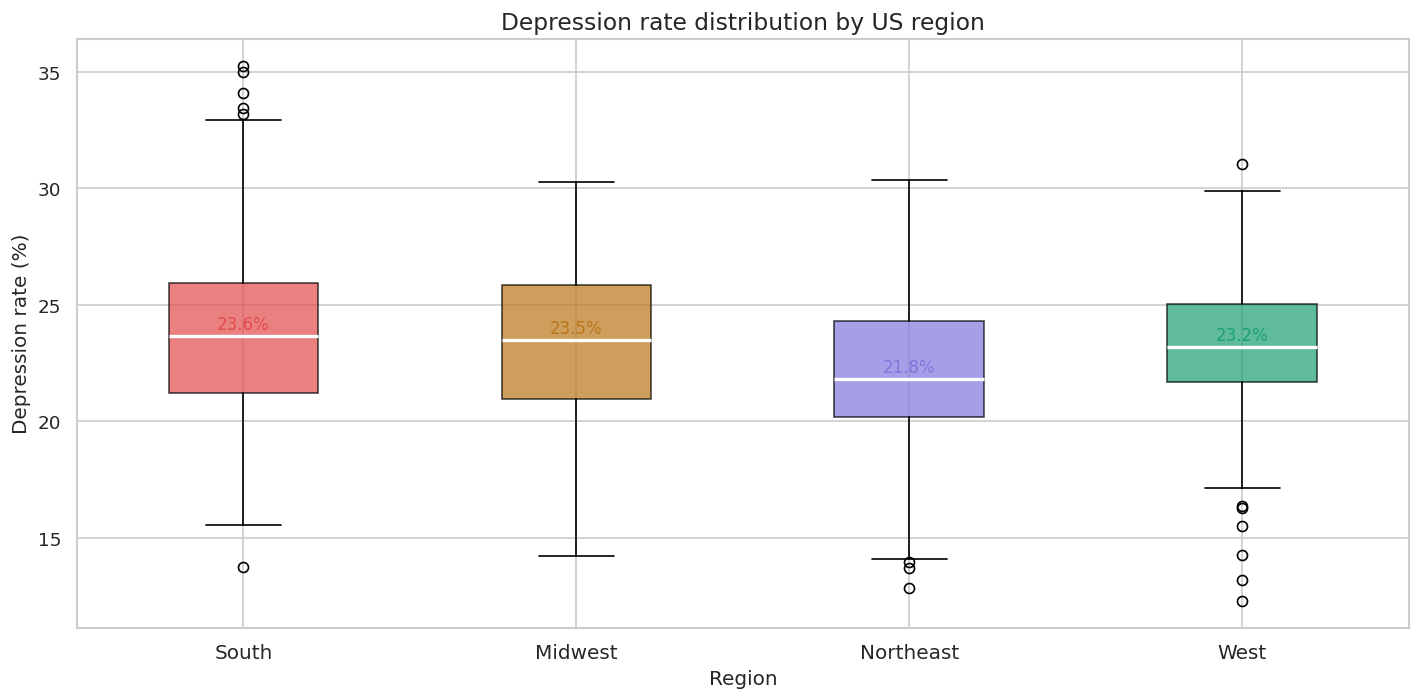

Chart 5 saved!


In [29]:
# Define US regions
region_map = {
    'Alabama': 'South', 'Arkansas': 'South', 'Florida': 'South',
    'Georgia': 'South', 'Kentucky': 'South', 'Louisiana': 'South',
    'Mississippi': 'South', 'North Carolina': 'South', 'South Carolina': 'South',
    'Tennessee': 'South', 'Virginia': 'South', 'West Virginia': 'South',
    'Texas': 'South', 'Oklahoma': 'South',
    'Illinois': 'Midwest', 'Indiana': 'Midwest', 'Iowa': 'Midwest',
    'Kansas': 'Midwest', 'Michigan': 'Midwest', 'Minnesota': 'Midwest',
    'Missouri': 'Midwest', 'Nebraska': 'Midwest', 'North Dakota': 'Midwest',
    'Ohio': 'Midwest', 'South Dakota': 'Midwest', 'Wisconsin': 'Midwest',
    'Connecticut': 'Northeast', 'Maine': 'Northeast', 'Massachusetts': 'Northeast',
    'New Hampshire': 'Northeast', 'New Jersey': 'Northeast', 'New York': 'Northeast',
    'Pennsylvania': 'Northeast', 'Rhode Island': 'Northeast', 'Vermont': 'Northeast',
    'Maryland': 'Northeast', 'Delaware': 'Northeast',
    'Arizona': 'West', 'California': 'West', 'Colorado': 'West',
    'Idaho': 'West', 'Montana': 'West', 'Nevada': 'West',
    'New Mexico': 'West', 'Oregon': 'West', 'Utah': 'West',
    'Washington': 'West', 'Wyoming': 'West',
    'Alaska': 'West', 'Hawaii': 'West'
}

master['region'] = master['state'].map(region_map) ## enriching a dataset by mapping one value to another.
master['region'] = master['region'].fillna('Other')

fig, ax = plt.subplots(figsize=(12, 6))

region_order = ['South', 'Midwest', 'Northeast', 'West']
colors_region = ['#E24B4A', '#BA7517', '#7F77DD', '#1D9E75']

data_to_plot = [
    master[master['region'] == r]['depression_rate'].dropna()
    for r in region_order
]

bp = ax.boxplot(data_to_plot, patch_artist=True, notch=False,
                medianprops=dict(color='white', linewidth=2))

for patch, color in zip(bp['boxes'], colors_region):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax.set_xticklabels(region_order, fontsize=12)
ax.set_title('Depression rate distribution by US region', fontsize=14)
ax.set_xlabel('Region')
ax.set_ylabel('Depression rate (%)')

# Add median labels above each box
for i, (region, color) in enumerate(zip(region_order, colors_region)):
    median = master[master['region'] == region]['depression_rate'].median()
    ax.text(i + 1, median + 0.3, f'{median:.1f}%',
            ha='center', fontsize=10, fontweight='500', color=color)

plt.tight_layout()
plt.savefig('data/processed/chart5_regional.png', dpi=120)
plt.show()
print('Chart 5 saved!')

In [21]:
master.to_csv('data/processed/master.csv', index=False)
print('Master dataframe updated with region column!')
print(f'Final shape: {master.shape}')
print('\nEDA Complete! Summary of findings:')
print('1. Depression is highest in poor, rural Southern counties')
print('2. SCI paradox confirmed — higher connectivity hurts poor counties')
print('3. Income is visually the strongest predictor')
print('4. Regional pattern is clear — South struggles most')
print('\nReady for Step 5 — Feature Engineering and Modeling!')

Master dataframe updated with region column!
Final shape: (2947, 17)

EDA Complete! Summary of findings:
1. Depression is highest in poor, rural Southern counties
2. SCI paradox confirmed — higher connectivity hurts poor counties
3. Income is visually the strongest predictor
4. Regional pattern is clear — South struggles most

Ready for Step 5 — Feature Engineering and Modeling!


In [31]:
master.head(10)

,county,state,fips,population,depression_rate,mental_distress_rate,income,age,poverty,broadband,state_code,county_code,sci,poverty_rate,broadband_rate,income_quartile,region
0,Abbeville,South Carolina,45001,24434,24.00,18.55,45710,44.3,4072,6867,45,1,0.364204,16.665302,28.104281,Q1 Low,South
1,Acadia,Louisiana,22001,56489,31.00,22.20,42368,36.8,13209,16787,22,1,0.435191,23.383314,29.717290,Q1 Low,South
2,Accomack,Virginia,51001,33239,22.55,18.15,50601,47.1,5593,10899,51,1,0.410062,16.826619,32.789795,Q2 Mid-Low,South
3,Ada,Idaho,16001,524673,25.25,15.50,75115,37.7,43553,168392,16,1,0.510118,8.300980,32.094657,Q4 High,West
4,Adair,Iowa,19001,7389,21.05,17.25,57944,43.4,837,2424,19,1,0.433395,11.327649,32.805522,Q3 Mid-High,Midwest
5,Adair,Missouri,29001,25122,27.40,19.35,46639,28.1,5258,6971,29,1,0.528510,20.929862,27.748587,Q1 Low,Midwest
6,Adair,Oklahoma,40001,19627,26.65,21.75,37940,37.8,4814,3563,40,1,0.270307,24.527437,18.153564,Q1 Low,South
7,Adams,Idaho,16003,4903,22.75,16.35,52746,54.7,688,1184,16,3,0.295881,14.032225,24.148481,Q2 Mid-Low,West
8,Adams,Iowa,19003,3544,21.15,16.65,57981,46.7,424,1267,19,3,0.435711,11.963883,35.750564,Q3 Mid-High,Midwest
9,Adams,Colorado,8001,533365,20.50,17.00,78304,34.2,48959,159432,8,1,0.492962,9.179267,29.891725,Q4 High,West
